<a href="https://colab.research.google.com/github/rakshansingh12/protein-function-classification-ml/blob/main/03_model_training_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import pandas as pd

df = pd.read_csv("/protein_features.csv")
df.head()

,A,C,D,E,F,G,H,I,K,L,...,T,V,W,Y,length,molecular_weight,isoelectric_point,aromaticity,gravy,label
0,0.115523,0.018051,0.046931,0.079422,0.025271,0.115523,0.036101,0.032491,0.025271,0.104693,...,0.054152,0.108303,0.000000,0.021661,277.0,28955.5180,5.016803,0.046931,0.114079,1.0
1,0.127193,0.010965,0.063596,0.063596,0.039474,0.078947,0.019737,0.028509,0.024123,0.114035,...,0.052632,0.054825,0.013158,0.019737,456.0,50118.1914,5.703872,0.072368,-0.308333,1.0
2,0.120482,0.008032,0.052209,0.076305,0.008032,0.076305,0.024096,0.052209,0.016064,0.108434,...,0.060241,0.092369,0.008032,0.008032,249.0,27001.5057,5.187092,0.024096,-0.118876,1.0
3,0.111782,0.027190,0.045317,0.093656,0.015106,0.069486,0.021148,0.033233,0.012085,0.102719,...,0.066465,0.069486,0.015106,0.018127,331.0,36462.0996,4.925406,0.048338,-0.217221,1.0
4,0.113208,0.010782,0.053908,0.067385,0.018868,0.105121,0.024259,0.048518,0.026954,0.113208,...,0.051213,0.091644,0.010782,0.016173,371.0,39592.7800,5.657662,0.045822,0.011590,1.0


In [26]:
X = df.drop(columns=["label"])
y = df["label"]

print(X.shape)
print(y.shape)

(8913, 25)
(8913,)


separates features from labels.

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)


ValueError: Input y contains NaN.

In [28]:
df["label"].isna().sum()

np.int64(1)

In [29]:
df = df.dropna()

In [30]:
df["label"].isna().sum()

np.int64(0)

row with label 0 is dropped.

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

ValueError: Input y contains NaN.

In [32]:
df = df.dropna()

In [33]:
X = df.drop(columns=["label"])
y = df["label"]

In [34]:
y.isna().sum()

np.int64(0)

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [36]:
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(7129, 25) (1783, 25)
(7129,) (1783,)


Split successful.

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

scaling for fair contribution of all features.Logistic regression model requires feature scaling.

In [38]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=1000,
    n_jobs=-1
)

log_reg.fit(X_train_scaled, y_train)

ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: np.float64(1.0)

In [39]:
y_train.value_counts()

,count
label,
1.0,7129


In [40]:
X = df.drop(columns=["label"])
y = df["label"]

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [42]:
print(y_train.value_counts())
print(y_test.value_counts())

label
1.0    7129
Name: count, dtype: int64
label
1.0    1783
Name: count, dtype: int64


In [43]:
df["label"].value_counts()

,count
label,
1.0,8912


In [46]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 110.0 MB/s eta 0:00:00


In [47]:
from Bio import SeqIO
from Bio.SeqUtils import ProtParam
import pandas as pd
import re

In [49]:
enzyme_records = list(SeqIO.parse("/content/enzymes_clean.fasta", "fasta"))
non_enzyme_records = list(SeqIO.parse("/content/non_enzymes_clean.fasta", "fasta"))

print("Enzymes:", len(enzyme_records))
print("Non-enzymes:", len(non_enzyme_records))

Enzymes: 120035
Non-enzymes: 120035


In [50]:
amino_acids = list("ACDEFGHIKLMNPQRSTVWY")

def aa_composition(sequence):
    seq = str(sequence)
    length = len(seq)
    return {aa: seq.count(aa) / length for aa in amino_acids}

def physchem_features(sequence):
    analyzer = ProtParam.ProteinAnalysis(str(sequence))
    return {
        "length": len(sequence),
        "molecular_weight": analyzer.molecular_weight(),
        "isoelectric_point": analyzer.isoelectric_point(),
        "aromaticity": analyzer.aromaticity(),
        "gravy": analyzer.gravy()
    }

def extract_features(record):
    feats = {}
    feats.update(aa_composition(record.seq))
    feats.update(physchem_features(record.seq))
    return feats


In [52]:
import re

# Ambiguous or unsupported amino acids
AMBIGUOUS_AA_PATTERN = re.compile(r"[XBZJUO]")

In [54]:
def has_ambiguous_amino_acids(sequence):
    return bool(AMBIGUOUS_AA_PATTERN.search(str(sequence)))

In [55]:
# Before filtering
print("Before filtering:")
print("Enzymes:", len(enzyme_records))
print("Non-enzymes:", len(non_enzyme_records))

# Remove sequences containing O or other ambiguous amino acids
enzyme_records = [
    r for r in enzyme_records
    if not has_ambiguous_amino_acids(r.seq)
]

non_enzyme_records = [
    r for r in non_enzyme_records
    if not has_ambiguous_amino_acids(r.seq)
]

# After filtering
print("\nAfter filtering ambiguous amino acids (including O):")
print("Enzymes:", len(enzyme_records))
print("Non-enzymes:", len(non_enzyme_records))

Before filtering:
Enzymes: 120035
Non-enzymes: 120035

After filtering ambiguous amino acids (including O):
Enzymes: 120014
Non-enzymes: 120035


In [56]:
min_size = min(len(enzyme_records), len(non_enzyme_records))
min_size

120014

In [57]:
enzyme_records = enzyme_records[:min_size]
non_enzyme_records = non_enzyme_records[:min_size]

In [58]:
print("Balanced enzymes:", len(enzyme_records))
print("Balanced non-enzymes:", len(non_enzyme_records))

Balanced enzymes: 120014
Balanced non-enzymes: 120014


In [59]:
data = []

for r in enzyme_records:
    feats = extract_features(r)
    feats["label"] = 1
    data.append(feats)

for r in non_enzyme_records:
    feats = extract_features(r)
    feats["label"] = 0
    data.append(feats)

len(data)

240028

In [60]:
df = pd.DataFrame(data)

In [61]:
df = df.dropna()

In [62]:
df["label"].value_counts()

,count
label,
1,120014
0,120014


In [63]:
X = df.drop(columns=["label"])
y = df["label"]

In [64]:
y.value_counts()

,count
label,
1,120014
0,120014


In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [66]:
print(y_train.value_counts())
print(y_test.value_counts())

label
0    96011
1    96011
Name: count, dtype: int64
label
0    24003
1    24003
Name: count, dtype: int64


In [67]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, n_jobs=-1)
log_reg.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=1000, n_jobs=-1)

In [68]:
y_pred_lr = log_reg.predict(X_test_scaled)

In [69]:
from sklearn.metrics import accuracy_score, classification_report

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print(classification_report(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.7274090738657668
              precision    recall  f1-score   support

           0       0.74      0.69      0.72     24003
           1       0.71      0.76      0.74     24003

    accuracy                           0.73     48006
   macro avg       0.73      0.73      0.73     48006
weighted avg       0.73      0.73      0.73     48006



In [70]:
from sklearn.metrics import classification_report, accuracy_score

y_pred_lr = log_reg.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.7274090738657668
              precision    recall  f1-score   support

           0       0.74      0.69      0.72     24003
           1       0.71      0.76      0.74     24003

    accuracy                           0.73     48006
   macro avg       0.73      0.73      0.73     48006
weighted avg       0.73      0.73      0.73     48006



The model correctly classifies ~73% of proteins.

When the model predicts non-enzyme, it’s correct 74% of the time

It correctly finds 69% of all non-enzymes

Some non-enzymes are being misclassified as enzymes

When the model predicts enzyme, it’s correct 71% of the time

It correctly detects 76% of enzymes

Slight bias toward predicting enzymes

Macro and weighted averages are balanced this means no hidden class imbalance.

In [71]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)


RandomForestClassifier(max_depth=20, min_samples_leaf=2, n_estimators=200,
                       n_jobs=-1, random_state=42)

In [72]:
y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.9030537849435487
              precision    recall  f1-score   support

           0       0.92      0.88      0.90     24003
           1       0.89      0.93      0.91     24003

    accuracy                           0.90     48006
   macro avg       0.90      0.90      0.90     48006
weighted avg       0.90      0.90      0.90     48006



When the model predicts non-enzyme, it’s correct 92% of the time

It correctly identifies 88% of non-enzymes

Few false positives

It correctly finds 93% of enzymes

Slightly lower precision, which is acceptable

High recall is often preferred biologically

In [73]:
import pandas as pd

feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)


,0
length,0.114802
molecular_weight,0.102615
gravy,0.081136
isoelectric_point,0.074558
G,0.054550
S,0.054078
H,0.043708
D,0.043356
C,0.039973
L,0.032713


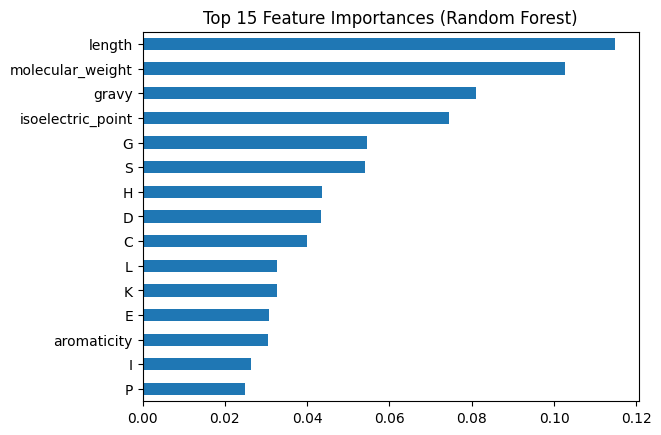

In [74]:
import matplotlib.pyplot as plt

feature_importance.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances (Random Forest)")
plt.show()

Protein length was the most informative feature, reflecting the structural complexity required for enzymatic activity

Enzymes often:
*   Have hydrophobic cores
*   Have hydrophilic active sites

Non-enzymes may be:
*   Highly hydrophobic (membrane proteins)
*   Or unstructured


Isoelectric point importance:

Enzymes bind substrates

Charge distribution matters for:
*  Catalysis
*  Binding


Amino acid composition importance:

Glycine → flexibility

Serine → active sites, phosphorylation

Enzymes often require:

Flexible regions

Reactive residues

Feature importance analysis showed that protein length, molecular weight, hydrophobicity, and isoelectric point were the strongest predictors. Additionally, residues like histidine, serine, and glycine were important, which aligns with their known roles in enzymatic catalysis and structural flexibility.

In [75]:
import joblib

joblib.dump(rf, "random_forest_protein_classifier.joblib")

['random_forest_protein_classifier.joblib']

In [76]:
rf_loaded = joblib.load("random_forest_protein_classifier.joblib")

In [77]:
!ls

enzymes_clean.fasta	 protein_features.csv			  sample_data
non_enzymes_clean.fasta  random_forest_protein_classifier.joblib
